# 📊 Superstore Sales - Exploratory Data Analysis
**Author:** Avanish Patwal  
**Dataset:** Sample Superstore (9800 rows, 18 columns)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

## Objective
Analyse the Superstore sales dataset to uncover trends in revenue, 
customer behaviour, product performance, and regional patterns.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("Libraries loaded ✅")

Libraries loaded ✅


In [15]:
df = pd.read_csv('SampleSuperstore.csv')
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [19]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [36]:
#data cleaning
df.columns=df.columns.str.strip().str.lower().str.replace(" ","_") 
df=df.drop_duplicates()

In [37]:
df.describe()


,row_id,postal_code,sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


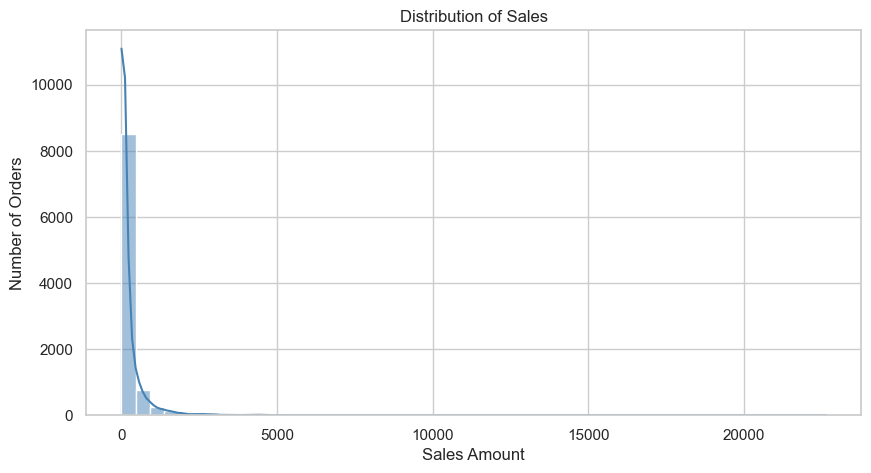

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['sales'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Number of Orders')
plt.show()

## 2. Sales Distribution
The sales distribution is highly right-skewed, meaning most orders are 
low value (under $500). A small number of high-value orders (>$5000) 
exist but are rare. This suggests the business relies on high volume 
of small transactions.

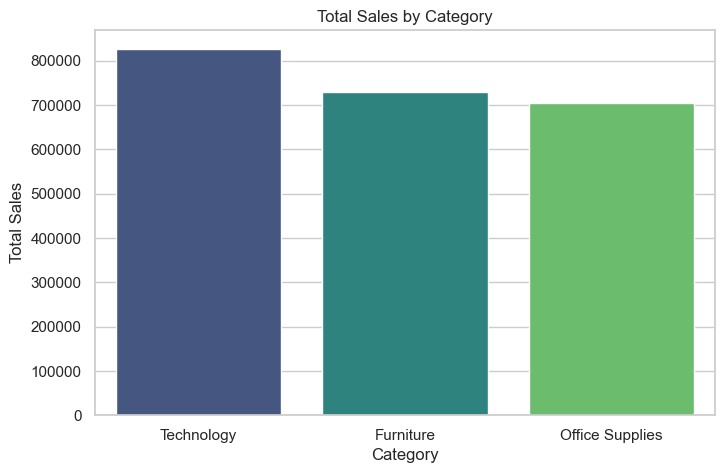

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [ ]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

print(category_sales)


## 3. Sales by Category
Technology is the highest revenue generating category, while Office 
Supplies has the lowest total sales. This suggests the business should 
focus marketing efforts on Technology products.

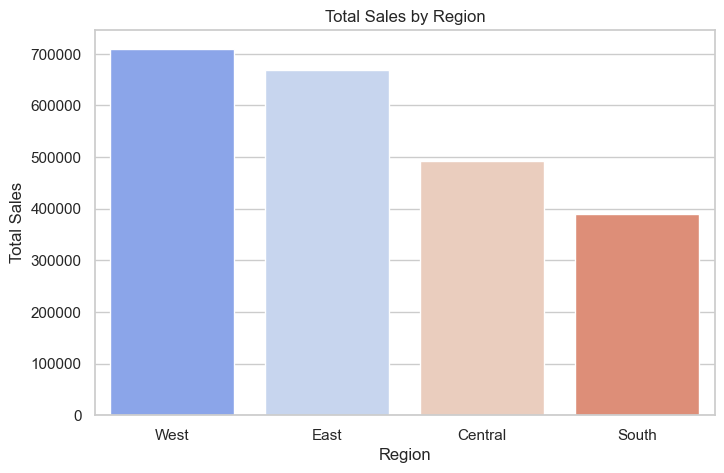

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [ ]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='coolwarm')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

print(region_sales)

## 4. Sales by Region
The West region generates the highest revenue while the South region 
has the lowest sales. This suggests the business should investigate 
why South is underperforming — could be less marketing, fewer customers, 
or lower population coverage.

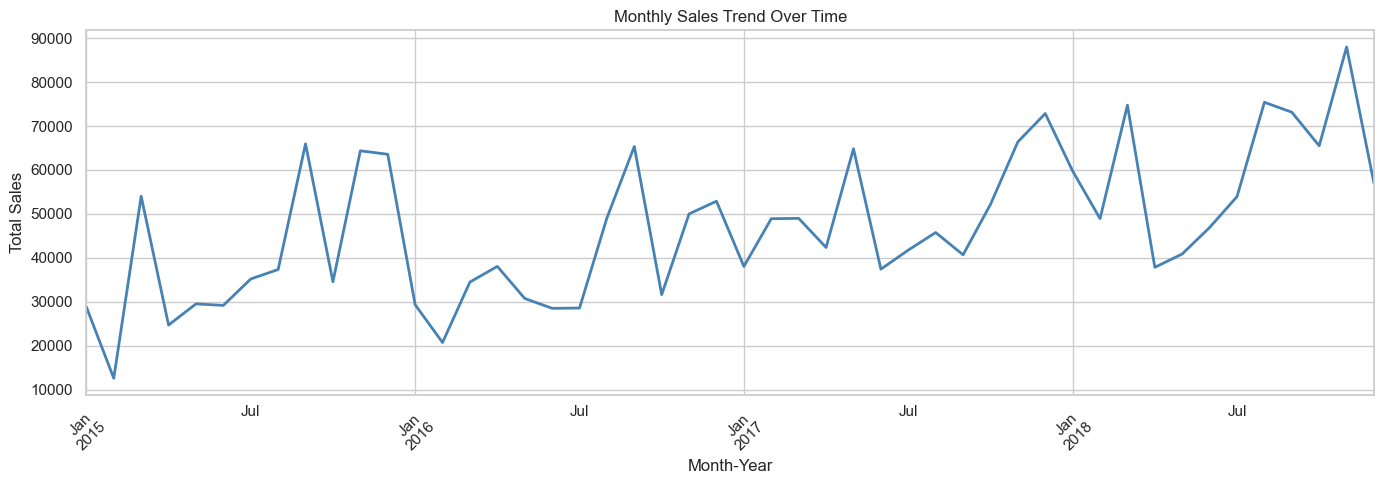

In [44]:
df['month-year'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('month-year')['sales'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(kind='line', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Monthly Sales Trend Over Time
This line chart shows how total sales changed month by month from 2015 to 2018.
The business shows a clear upward growth trend over 4 years.
Regular spikes and dips suggest seasonal patterns repeating every year.

## Sales by Month (All Years Combined)
To confirm the seasonal pattern observed in the trend chart, we aggregate 
sales by month across all years. This removes the year-by-year noise and 
clearly shows which months consistently perform best.
This directly answers whether the spikes are in Nov-Dec or some other months.

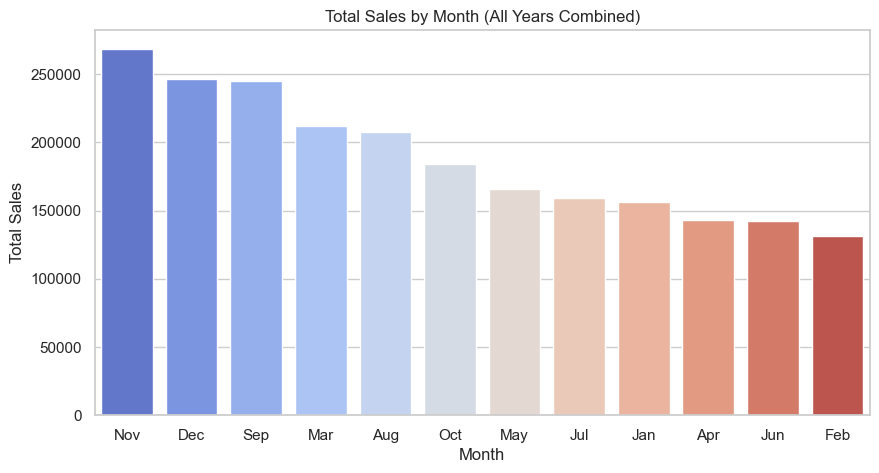

month
Nov    268768.7885
Dec    246266.5152
Sep    245155.0671
Mar    212256.1344
Aug    207601.7939
Oct    183851.9562
May    166000.7467
Jul    159472.5865
Jan    155990.9154
Apr    142984.2481
Jun    142034.7713
Feb    131153.2594
Name: sales, dtype: float64


In [45]:
df['month'] = df['order_date'].dt.month
monthly_avg = df.groupby('month')['sales'].sum().sort_values(ascending=False)

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly_avg.index = monthly_avg.index.map(month_names)

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='coolwarm')
plt.title('Total Sales by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

print(monthly_avg)

## Sales by Month (All Years Combined)
Aggregating sales across all years confirms that November and December 
are the highest performing months, validating the seasonal spikes seen 
in the trend chart. This is driven by holiday season shopping behaviour. 
January and February are consistently the weakest months — typical 
post-holiday slowdown.

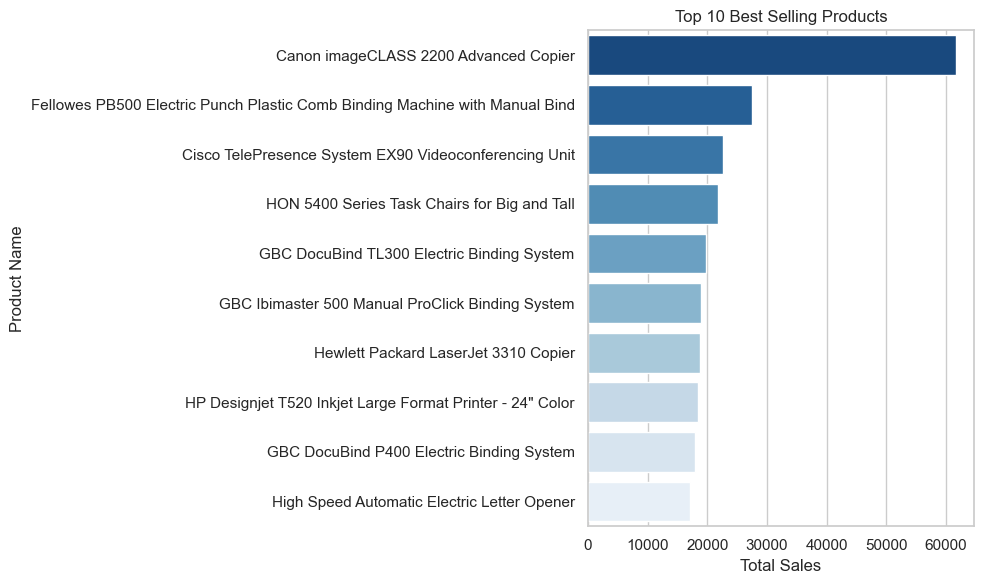

In [49]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

## Top 10 Best Selling Products
The top selling products are dominated by office technology equipment.
Canon imageCLASS 2200 Advanced Copier is the highest revenue generating 
product by a significant margin at $60,000 in total sales. 
All top 10 products fall under Technology or Office Equipment category, 
confirming that Technology drives the most revenue in this business.

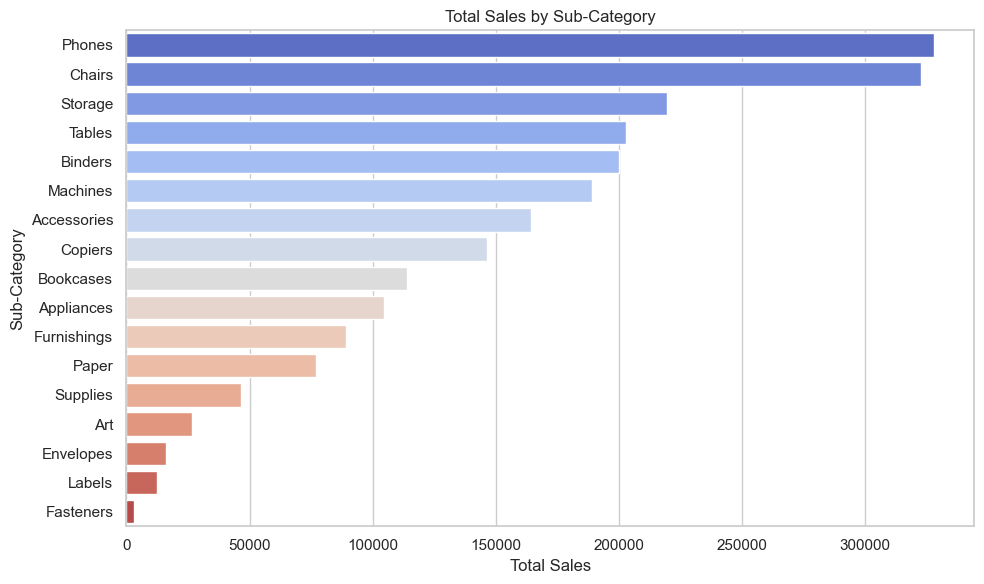

In [50]:
subcat_sales = df.groupby('sub-category')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=subcat_sales.values, y=subcat_sales.index, palette='coolwarm')
plt.title('Total Sales by Sub-Category')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

## Total Sales by Sub-Category
Phones and Chairs are the top two revenue generating sub-categories, 
confirming that Technology and Furniture drive the most sales. 
Fasteners, Labels and Envelopes are the lowest performing sub-categories 
— these are low-cost, low-volume items that contribute minimally to revenue.
This insight can help the business decide where to focus inventory and 
marketing investments.

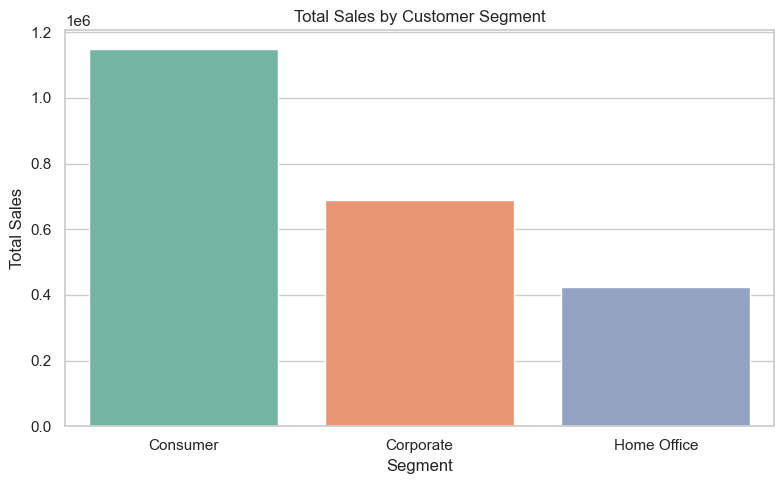

segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: sales, dtype: float64


In [51]:
segment_sales = df.groupby('segment')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_sales.index, y=segment_sales.values, palette='Set2')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

print(segment_sales)

## Sales by Customer Segment
Consumer segment generates the highest revenue, followed by Corporate 
and Home Office. This suggests the business is primarily B2C (business 
to consumer) driven. However, Corporate customers likely place fewer 
but larger orders — worth investigating further.

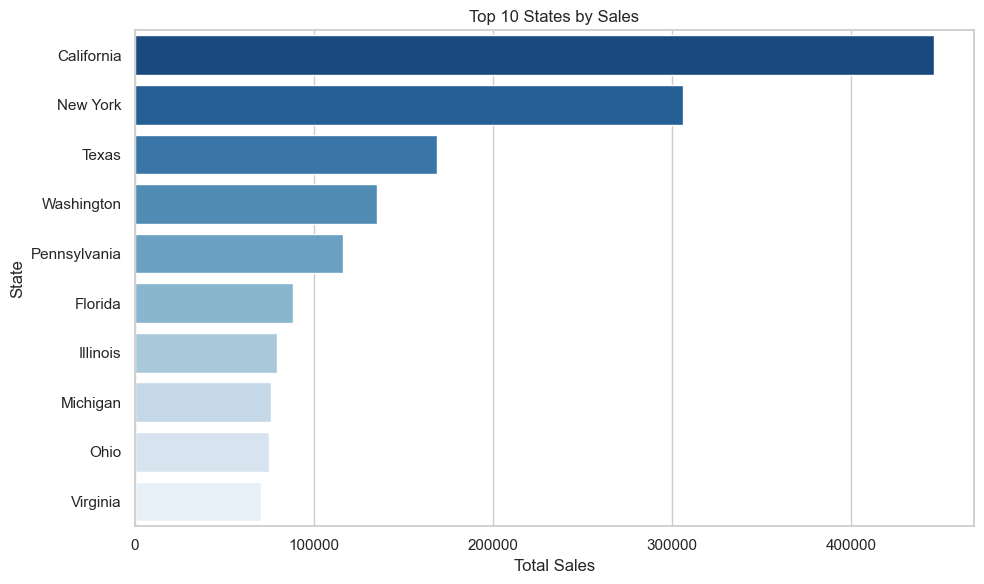

In [52]:
state_sales = df.groupby('state')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=state_sales.values, y=state_sales.index, palette='Blues_r')
plt.title('Top 10 States by Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Top 10 States by Sales
California, New York and Texas are the top 3 revenue generating states.
This directly correlates with population size and economic activity — 
these are the largest business hubs in the USA. The business has strong 
presence in coastal states (California, New York) vs central states 
which appear lower in the ranking. Expanding coverage in mid-tier states 
could be a growth opportunity.

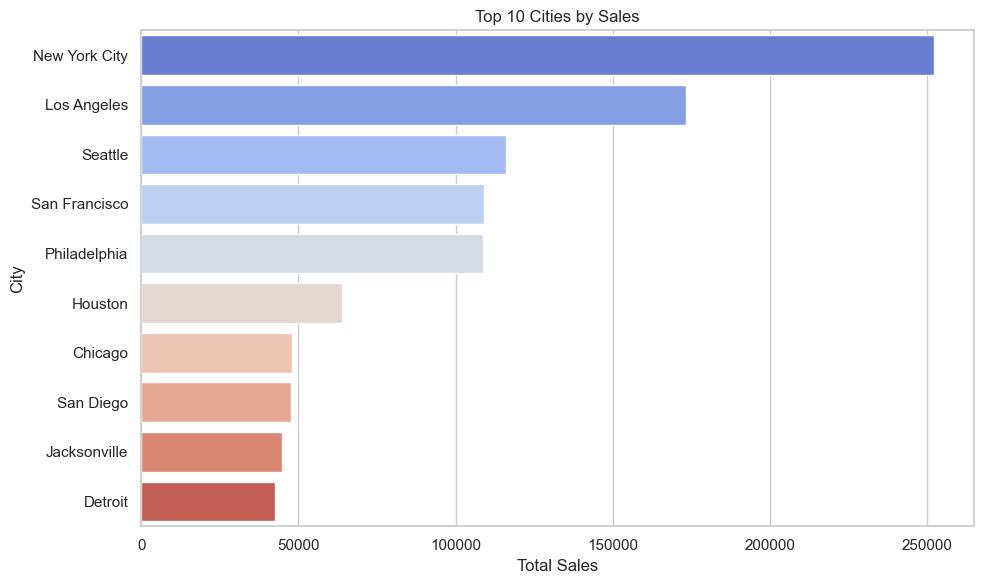

In [57]:
city_sales = df.groupby('city')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=city_sales.values, y=city_sales.index, palette='coolwarm')
plt.title('Top 10 Cities by Sales')
plt.xlabel('Total Sales')
plt.ylabel('City')
plt.tight_layout()
plt.show()

## Top 10 Cities by Sales
New York City is the highest revenue generating city by a significant 
margin at ~$250,000, followed by Los Angeles at ~$175,000. Both cities 
are in the top 3 states (New York and California) confirming that 
state-level and city-level trends are consistent. Seattle and San 
Francisco appearing in top 5 suggests strong tech-savvy customer base 
purchasing Technology products.

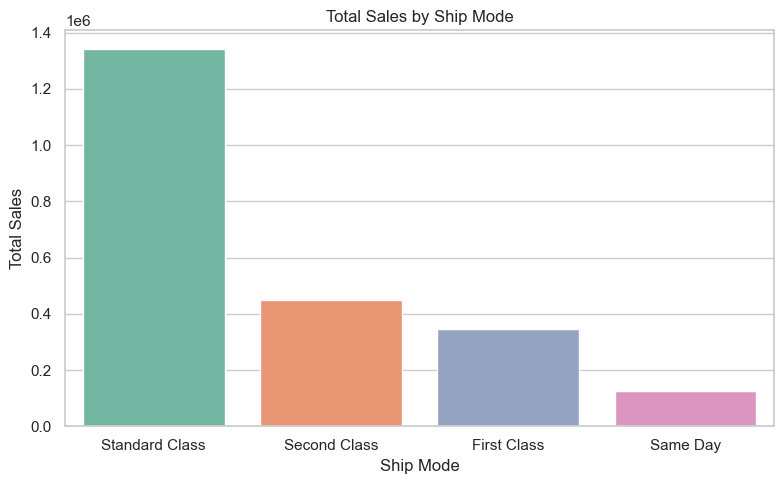

ship_mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: sales, dtype: float64


In [55]:
ship_sales = df.groupby('ship_mode')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=ship_sales.index, y=ship_sales.values, palette='Set2')
plt.title('Total Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

print(ship_sales)

## Sales by Ship Mode
Standard Class is the most preferred shipping method, generating over 
$1.3 million in sales — nearly 3x more than Second Class. Same Day 
delivery has the lowest sales, likely due to higher shipping costs. 
This suggests most customers prioritise cost over speed when choosing 
delivery options.

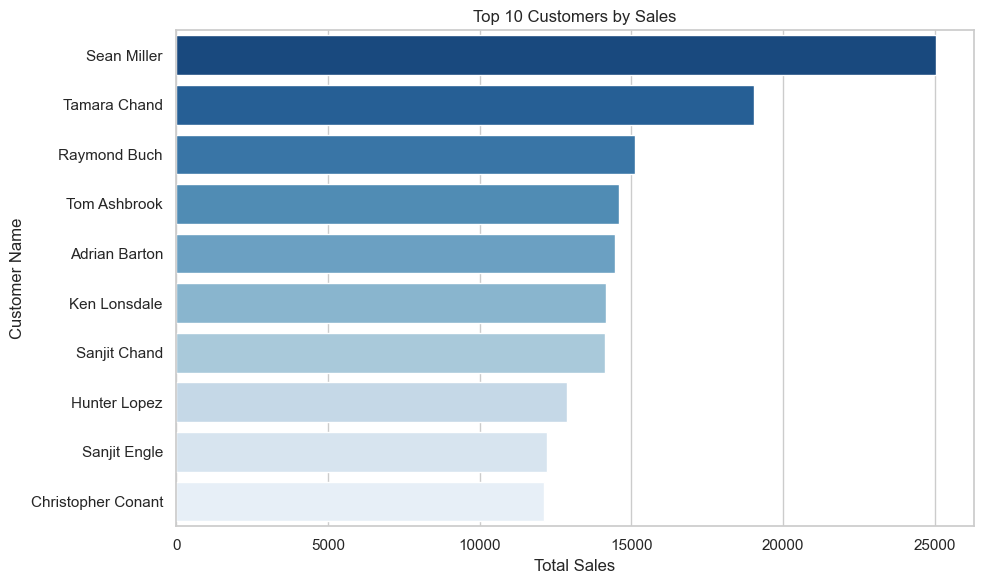

In [56]:
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette='Blues_r')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.show()

## Top 10 Customers by Sales
Sean Miller, Tamara Chand and Raymond Buch are the top 3 highest 
spending customers. These are high value customers who should be 
prioritised for loyalty programs, special discounts and dedicated 
account management to ensure retention. Losing even one of these 
customers would significantly impact revenue.

In [58]:
print("""
=== SUPERSTORE SALES - KEY INSIGHTS ===

1. SALES DISTRIBUTION: Highly right-skewed — most orders under $500, 
   few high value orders above $5000.

2. TOP CATEGORY: Technology generates the highest revenue.

3. TOP REGION: West region leads in sales, South is lowest.

4. SEASONALITY: Sales peak every November-December (holiday season) 
   and dip every January-February.

5. TOP PRODUCT: Canon imageCLASS 2200 Advanced Copier is #1 product.

6. TOP SUB-CATEGORY: Phones and Chairs lead all sub-categories.

7. CUSTOMER SEGMENT: Consumer segment drives the most revenue.

8. TOP STATE: California, New York, Texas are top 3 states.

9. SHIPPING: 80% of customers prefer Standard Class shipping.

10. TOP CUSTOMER: Sean Miller is the highest spending customer.
""")


=== SUPERSTORE SALES - KEY INSIGHTS ===

1. SALES DISTRIBUTION: Highly right-skewed — most orders under $500, 
   few high value orders above $5000.

2. TOP CATEGORY: Technology generates the highest revenue.

3. TOP REGION: West region leads in sales, South is lowest.

4. SEASONALITY: Sales peak every November-December (holiday season) 
   and dip every January-February.

5. TOP PRODUCT: Canon imageCLASS 2200 Advanced Copier is #1 product.

6. TOP SUB-CATEGORY: Phones and Chairs lead all sub-categories.

7. CUSTOMER SEGMENT: Consumer segment drives the most revenue.

8. TOP STATE: California, New York, Texas are top 3 states.

9. SHIPPING: 80% of customers prefer Standard Class shipping.

10. TOP CUSTOMER: Sean Miller is the highest spending customer.

